In [20]:
import uuid
import os
import json
from pathlib import Path
from typing import Literal, TypedDict
import time

from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver

from IPython.display import Image, display
from langchain_community.document_loaders import PyPDFLoader, TextLoader


In [21]:
import getpass
import os

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_API_KEY"] = getpass.getpass()


In [34]:
os.environ["GROQ_API_KEY"] = getpass.getpass("Groq API Key: ")

In [23]:
folder = Path(r"C:\Users\samya\OneDrive\Desktop\Intern\LegalContractReviewer\ContractTemplates\Standards&Guidelines")

sources = list(folder.glob("*.pdf"))

print(f"Found {len(sources)} files:")
for s in sources:
    print(f"  {s.name}")

Found 2 files:
  contract_risk_guidelines.pdf
  contract_template_library.pdf


In [24]:
def load_documents(folder):
    docs = []
    
    for filepath in folder.rglob("*.pdf"):
        loader = PyPDFLoader(str(filepath))
        loaded_docs = loader.load() 
        
        if "template_library" in filepath.name.lower():
            risk_profile = "standard"
        else:
            risk_profile = "guidelines"
        
        for doc in loaded_docs:
            doc.metadata["source"] = filepath.name
            doc.metadata["risk_profile"] = risk_profile
            docs.append(doc)
        print(f"{filepath.name} → [{risk_profile}]")
    
    return docs

def chunk_documents(docs):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=600,
        chunk_overlap=100,
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    chunks = splitter.split_documents(docs)
    print(f"Split into {len(chunks)} chunks")
    return chunks

def build_vector_store(folder):
    print("\n📚 Building document index...")
    docs = load_documents(folder)
    chunks = chunk_documents(docs)

    print(f"Embedding with Ollama (nomic-embed-text)...")
    embeddings = OllamaEmbeddings(model="nomic-embed-text")
    vs = FAISS.from_documents(chunks, embeddings)
    print(f"Index ready — {len(chunks)} vectors stored\n")
    return vs

def retrieve(vector_store,query, k=4, max_distance=1.2):
    results = vector_store.similarity_search_with_score(query, k=k)
    results = [(doc, score) for doc, score in results if score < max_distance]
    texts = [doc.page_content for doc, _score in results]
    scores = [round(float(score), 4) for _doc, score in results]
    return texts, scores

vector_store = build_vector_store(folder)
texts, scores = retrieve(vector_store, "liability cap clause")





📚 Building document index...
contract_risk_guidelines.pdf → [guidelines]
contract_template_library.pdf → [standard]
Split into 213 chunks
Embedding with Ollama (nomic-embed-text)...
Index ready — 213 vectors stored



In [25]:
class ContractClassification(TypedDict):
    RiskLevel: Literal["low", "medium", "high", "critical"]
    ClauseType: Literal[
        "payment_terms",
        "termination",
        "liability_cap",
        "data_ownership",
        "auto_renewal",
        "ip_ownership",
        "non_compete",
        "indemnification",
        "breach_notification",
        "other"
    ]
    ActionRequired: Literal["Reject","Negotiate", "Flag", "Accept"]
    Deviation: str        
    Recommendation: str

class ContractReviewState(TypedDict):

    contract_text: str
    contract_name: str
    client_name: str
    review_id: str

    contract_type: Literal[
        "saas",
        "consulting",
        "employment",
        "vendorsupply",
        "dataprocessing",
        "other"
    ] | None

    extracted_clauses: list[str] | None
    classifications: list[ContractClassification] | None
    retrieved_context: list[str] | None

    draft_findings: list[str] | None
    final_report: str | None

    needs_human_review: bool
    human_feedback: dict | None

    ticket_id: str | None
    status: Literal[
        "Pending",
        "InReview",
        "Escalated",
        "Complete"
    ] | None


In [35]:
#llm = ChatOllama(model="llama3.2", temperature=0.2)

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.2,
    api_key=os.environ["GROQ_API_KEY"]
)

In [27]:
def ReadContract(state: ContractReviewState) -> ContractReviewState:

    body = state.get("contract_text", "").strip()
    if not body:
        raise ValueError("Empty Contract Received.")
    ticket_id = f"LEG-{uuid.uuid4().hex[:8].upper()}"
    review_id = str(uuid.uuid4())
    contract_name = state.get("contract_name", "Unknown")
    client_name = state.get("client_name", "Unknown")
    return {
        "contract_text": body,
        "contract_name": contract_name,
        "client_name": client_name,
        "review_id": review_id,
        "ticket_id": ticket_id,
        "status": "Pending",
        "needs_human_review": False
    }

def ClassifyContract(state: ContractReviewState) -> ContractReviewState:

    Text = state.get("contract_text", "")

    Start = Text[:1000]
    Mid = Text[len(Text)//2 - 500 : len(Text)//2 + 500]
    End = Text[-500:]
    Sample = f"[START]\n{Start}\n\n[MIDDLE]\n{Mid}\n\n[END]\n{End}"

    Prompt = f"""You are a legal assistant. Classify the type of this contract based on its content.

    Contract Sample:
    \"\"\"{Sample}\"\"\"

    Contract Type Definitions:
    - Consulting: Agreement where an independent consultant or firm provides advisory or professional services to a client for a fee. Key markers: scope of work, deliverables, consulting fees, independent contractor clause.
    - DataProcessing: Agreement governing how a data processor handles personal data on behalf of a data controller. Key markers: GDPR, data subjects, processing instructions, sub-processors, data breach notification.
    - Employment: Agreement between an employer and an individual employee establishing terms of work. Key markers: salary, designation, working hours, probation period, notice period, employee obligations.
    - SaaS: Agreement granting a client access to software hosted by a vendor over the internet. Key markers: subscription fees, uptime SLA, user licences, data hosting, software updates, acceptable use policy.
    - VendorSupply: Agreement for the supply of physical goods or non-software services from a vendor to a buyer. Key markers: purchase orders, delivery terms, inspection, warranties on goods, title and risk of loss.
    - Other: Use only if the contract does not clearly fit any of the above types.

    Respond ONLY with a valid JSON object (no markdown, no extra text):
    {{
        "ContractType": "<one of: consulting, dataprocessing, employment, saas, vendorsupply, other>"
    }}
    """

    print("Invoking LLM for contract classification...")
    Response = llm.invoke(Prompt)
    Content = Response.content.strip()

    ContractType = "other"

    try:
        if "```" in Content:
            Content = Content.split("```")[1]
            if Content.startswith("json"):
                Content = Content[4:]
            Content = Content.strip()
        Parsed = json.loads(Content)
        ContractType = Parsed.get("ContractType", "other").lower().strip()
    except Exception as e:
        print(f"Parse failed: {type(e).__name__}: {e}")
        ContractType = "other"

    Allowed = ["consulting", "dataprocessing", "employment", "saas", "vendorsupply", "other"]
    if ContractType not in Allowed:
        print(f"'{ContractType}' not in allowed list, defaulting to 'other'")
        ContractType = "other"

    print(f"Contract Type: {ContractType}")
    return {"contract_type": ContractType}

def DeduplicateClauses(Clauses: list[str], Threshold: int = 80) -> list[str]:
    Unique = []
    for Clause in Clauses:
        IsDuplicate = False
        ClauseWords = set(Clause.lower().split())
        for Existing in Unique:
            ExistingWords = set(Existing.lower().split())
            if len(ClauseWords) == 0 or len(ExistingWords) == 0:
                continue
            Overlap = len(ClauseWords & ExistingWords)
            Similarity = (Overlap / max(len(ClauseWords), len(ExistingWords))) * 100
            if Similarity >= Threshold:
                IsDuplicate = True
                break
        if not IsDuplicate:
            Unique.append(Clause)
    return Unique


def ExtractClauses(state: ContractReviewState) -> ContractReviewState:

    ContractText = state.get("contract_text", "")

    Prompt = f"""You are a legal document analyst. Extract every numbered clause from this contract.

    Rules:
    - Include the clause number, heading, and full text
    - Do not merge multiple sub-clauses into one entry
    - Do not skip any sub-clause
    - Do not summarize or shorten the text
    - Do not hallucinate clauses that are not present

    Contract Text:
    \"\"\"{ContractText}\"\"\"

    Respond ONLY with valid JSON, no markdown, no extra text:
    {{
        "clauses": [
            "1.1 HEADING — full clause text here",
            "1.2 HEADING — full clause text here"
        ]
    }}
    """

    Response = llm.invoke(Prompt)
    Content = Response.content.strip()

    try:
        if "```" in Content:
            Content = Content.split("```")[1]
            if Content.startswith("json"):
                Content = Content[4:]
            Content = Content.strip()

        Parsed = json.loads(Content)
        Clauses = Parsed.get("clauses", [])

        if not isinstance(Clauses, list):
            Clauses = []

        Clauses = [str(c).strip() for c in Clauses if c]

        if not Clauses:
            raise ValueError("Empty clauses list")

    except (json.JSONDecodeError, ValueError):
        Clauses = []

    print(f"Extracted {len(Clauses)} clauses")

    Clauses = DeduplicateClauses(Clauses, Threshold=80)
    print(f"After deduplication: {len(Clauses)} clauses")

    return {"extracted_clauses": Clauses}

def SearchRAG(state: ContractReviewState) -> ContractReviewState:

    clauses = state.get("extracted_clauses", [])
    contract_type = state.get("contract_type", "")

    if not clauses:
        print("No clauses found to search")
        return {"retrieved_context": []}
    all_contexts = []
    for i, clause in enumerate(clauses):
        qry = f"{contract_type} {clause[:200]}"
        texts, scores = retrieve(vector_store, qry, k=3)
        conte = "\n---\n".join(texts)
        all_contexts.append(conte)

        print(f"Clause {i+1}: retrieved {len(texts)} chunks (L2 distance: {scores[0] if scores else 'N/A'})") #Lower is better for L2 distance

    print(f"RAG search complete — {len(all_contexts)} contexts retrieved")

    return {"retrieved_context": all_contexts}

def CheckIssues(state: ContractReviewState) -> ContractReviewState:

    Clauses = state.get("extracted_clauses", [])
    RetrievedContext = state.get("retrieved_context", [])
    ContractType = state.get("contract_type", "")

    if not Clauses:
        print("No clauses to check")
        return {"classifications": [], "needs_human_review": False}

    Classifications = []

    for I, (Clause, Context) in enumerate(zip(Clauses, RetrievedContext)):

        Prompt = f"""You are a legal risk analyst.
        Analyze this contract clause and assess the risk for our client.

        Contract Type: {ContractType}

        Clause Text:
        \"\"\"{Clause}\"\"\"

        Relevant Standard Template:
        \"\"\"{Context}\"\"\"

        Respond ONLY with a valid JSON object (no markdown, no extra text):
        {{
            "ClauseType": "<one of: payment_terms, termination, liability_cap, data_ownership, auto_renewal, ip_ownership, non_compete, indemnification, breach_notification, other>",
            "RiskLevel": "<one of: low, medium, high, critical>",
            "ActionRequired": "<one of: Accept, Negotiate, Flag, Reject>",
            "Deviation": "<one sentence — what is different from the standard version>",
            "Recommendation": "<one sentence — what the client should do>"
        }}

        Risk classification rules (apply these in order — stop at the first match):
        - critical: the clause removes a protection that is non-negotiable in this contract type,
        or creates an uncapped/unlimited obligation on the client,
        or gives the vendor rights that cannot be reversed once the contract is signed
        - high: the clause gives the vendor a significant advantage the client cannot easily recover from,
        or exposes the client to financial liability beyond what is standard for this contract type,
        or restricts the client's ability to exit, dispute, or seek remedy
        - medium: the clause deviates from the standard version in the reference but the client
        can recover through negotiation or has partial protections remaining
        - low: the clause is consistent with the reference standard or is only marginally different

        IMPORTANT:
        - Use the reference standard to calibrate your judgment — if the clause is significantly worse than the reference, that is at minimum high risk
        - If the reference standard mentions this clause as a red flag, that is at minimum high risk
        - Do not default to medium when uncertain — if a clause removes client rights, lean toward high or critical
        - The client is the one exposed to risk in a vendor-friendly contract
        """

        Response = llm.invoke(Prompt)
        Content = Response.content.strip()

        try:
            if "```" in Content:
                Content = Content.split("```")[1]
                if Content.startswith("json"):
                    Content = Content[4:]
                Content = Content.strip()

            Parsed = json.loads(Content)

            Classification = {
                "ClauseType": Parsed.get("ClauseType", "other"),
                "RiskLevel": Parsed.get("RiskLevel", "high"),
                "ActionRequired": Parsed.get("ActionRequired", "Flag"),
                "Deviation": Parsed.get("Deviation", ""),
                "Recommendation": Parsed.get("Recommendation", "")
            }

        except (json.JSONDecodeError, ValueError):
            Classification = {
                "ClauseType": "other",
                "RiskLevel": "high",
                "ActionRequired": "Flag",
                "Deviation": "Could not analyse this clause automatically",
                "Recommendation": "Manual review required"
            }

        Classifications.append(Classification)
        print(f"Clause {I+1}: {Classification['ClauseType']} — {Classification['RiskLevel']}")
        time.sleep(5)

    NeedsHumanReview = any(
        C["RiskLevel"] in ["high", "critical"] for C in Classifications
    )

    print(f"Check complete — {len(Classifications)} clauses analysed")
    print(f"Human review required: {NeedsHumanReview}")

    return {
        "classifications": Classifications,
        "needs_human_review": NeedsHumanReview
    }


In [28]:
def DraftFinding(state: ContractReviewState) -> ContractReviewState:

    Clauses = state.get("extracted_clauses", [])
    Classifications = state.get("classifications", [])
    ContractType = state.get("contract_type", "")
    ClientName = state.get("client_name", "Unknown")

    if not Clauses or not Classifications:
        print("No clauses or classifications found")
        return {"draft_findings": []}

    DraftFindings = []

    for I, (Clause, Classification) in enumerate(zip(Clauses, Classifications)):

        Prompt = f"""You are a legal consultant at a Big 4 firm writing a contract review finding for your client.

        Client: {ClientName}
        Contract Type: {ContractType}

        Clause Text:
        \"\"\"{Clause}\"\"\"

        Clause Analysis:
        - Clause Type: {Classification['ClauseType']}
        - Risk Level: {Classification['RiskLevel']}
        - Action Required: {Classification['ActionRequired']}
        - Deviation: {Classification['Deviation']}
        - Recommendation: {Classification['Recommendation']}

        Write a professional finding for this clause in 3-4 sentences.
        Structure it as:
        1. What the clause says
        2. Why it is risky for the client
        3. What the client should do

        Respond with plain text only. No JSON, no bullet points, no headers.
        """

        Response = llm.invoke(Prompt)
        Finding = Response.content.strip()

        if not Finding:
            Finding = f"Clause {I+1} requires manual review — automated analysis unavailable."

        DraftFindings.append(Finding)
        print(f"Clause {I+1}: finding drafted — {Classification['RiskLevel']} risk")
        time.sleep(5)

    print(f"Draft findings complete - {len(DraftFindings)} findings written")

    return {"draft_findings": DraftFindings}

def LawyerReview(state: ContractReviewState) -> ContractReviewState:
    Classifications = state.get("classifications", [])
    Clauses = state.get("extracted_clauses", [])
    ClientName = state.get("client_name", "Unknown")
    ContractName = state.get("contract_name", "Unknown")
    TicketId = state.get("ticket_id", "Unknown")

    CriticalCount = sum(1 for C in Classifications if C["RiskLevel"] == "critical")
    HighCount     = sum(1 for C in Classifications if C["RiskLevel"] == "high")
    MediumCount   = sum(1 for C in Classifications if C["RiskLevel"] == "medium")
    LowCount      = sum(1 for C in Classifications if C["RiskLevel"] == "low")

    HighCriticalClauses = []
    for I, (Clause, Classification) in enumerate(zip(Clauses, Classifications)):
        if Classification["RiskLevel"] in ["high", "critical"]:
            HighCriticalClauses.append({
                "Index": I + 1,
                "ClauseType": Classification["ClauseType"],
                "RiskLevel": Classification["RiskLevel"],
                "ActionRequired": Classification["ActionRequired"],
                "Recommendation": Classification["Recommendation"]
            })

    ReviewData = interrupt({
        "contract_name": ContractName,
        "client_name": ClientName,
        "ticket_id": TicketId,
        "total_clauses": len(Clauses),
        "critical": CriticalCount,
        "high": HighCount,
        "medium": MediumCount,
        "low": LowCount,
        "high_critical_clauses": HighCriticalClauses
    })

    return {"human_feedback": ReviewData}

In [29]:
def GenerateReport(state: ContractReviewState) -> ContractReviewState:
    from reportlab.lib.pagesizes import A4
    from reportlab.lib import colors
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.lib.units import cm
    from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, HRFlowable, PageBreak

    Classifications = state.get("classifications", [])
    DraftFindings = state.get("draft_findings", [])
    Clauses = state.get("extracted_clauses", [])
    ClientName = state.get("client_name", "Unknown")
    ContractName = state.get("contract_name", "Unknown")
    ContractType = state.get("contract_type", "Unknown")
    TicketId = state.get("ticket_id", "Unknown")

    CriticalCount = sum(1 for C in Classifications if C["RiskLevel"] == "critical")
    HighCount = sum(1 for C in Classifications if C["RiskLevel"] == "high")
    MediumCount = sum(1 for C in Classifications if C["RiskLevel"] == "medium")
    LowCount = sum(1 for C in Classifications if C["RiskLevel"] == "low")

    OutputPath = f"Draft_Review_{TicketId}.pdf"
    Doc = SimpleDocTemplate(OutputPath, pagesize=A4, rightMargin=2*cm, leftMargin=2*cm, topMargin=2*cm, bottomMargin=2*cm)
    Story = []
    
    Styles = getSampleStyleSheet()
    TitleStyle = ParagraphStyle("TitleStyle", parent=Styles["Title"], fontSize=18, textColor=colors.black, spaceAfter=10)
    SectionHeadingStyle = ParagraphStyle("SectionHeading", parent=Styles["Heading1"], fontSize=12, textColor=colors.black, spaceBefore=12, spaceAfter=6)
    BodyStyle = ParagraphStyle("BodyStyle", parent=Styles["Normal"], fontSize=10, leading=14, textColor=colors.black)
    BoldBodyStyle = ParagraphStyle("BoldBodyStyle", parent=Styles["Normal"], fontSize=10, leading=14, textColor=colors.black, fontName="Helvetica-Bold")
    
    Story.append(Paragraph("DRAFT — FOR LEGAL REVIEW ONLY", BoldBodyStyle))
    Story.append(Spacer(1, 0.5*cm))
    Story.append(Paragraph(f"Draft Contract Risk Review: {ContractName}", TitleStyle))
    Story.append(Paragraph(f"Client: {ClientName} | Type: {ContractType.upper()} | Ticket: {TicketId}", BodyStyle))
    Story.append(Spacer(1, 0.5*cm))
    
    Story.append(Paragraph("Risk Summary Table", SectionHeadingStyle))
    SummaryData = [
        [Paragraph("Risk Level", BoldBodyStyle), Paragraph("Clause Count", BoldBodyStyle)],
        [Paragraph("CRITICAL", BodyStyle), Paragraph(str(CriticalCount), BodyStyle)],
        [Paragraph("HIGH", BodyStyle), Paragraph(str(HighCount), BodyStyle)],
        [Paragraph("MEDIUM", BodyStyle), Paragraph(str(MediumCount), BodyStyle)],
        [Paragraph("LOW", BodyStyle), Paragraph(str(LowCount), BodyStyle)],
    ]
    SummaryTable = Table(SummaryData, colWidths=[6*cm, 6*cm])
    SummaryTable.setStyle(TableStyle([
        ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
        ("TOPPADDING", (0, 0), (-1, -1), 5),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
    ]))
    Story.append(SummaryTable)
    Story.append(Spacer(1, 0.5*cm))
    
    Story.append(Paragraph("Clause-by-Clause Findings", SectionHeadingStyle))
    for I, (Clause, Classification, Finding) in enumerate(zip(Clauses, Classifications, DraftFindings)):
        Story.append(Spacer(1, 0.3*cm))
        Story.append(Paragraph(f"Clause {I+1}: {Classification['ClauseType'].upper().replace('_', ' ')}", BoldBodyStyle))
        Story.append(Paragraph(f"Risk Level: {Classification['RiskLevel'].upper()} | Action Required: {Classification['ActionRequired']}", BodyStyle))
        Story.append(Paragraph(f"Deviation: {Classification.get('Deviation', '')}", BodyStyle))
        Story.append(Paragraph(f"Recommendation: {Classification.get('Recommendation', '')}", BodyStyle))
        Story.append(Paragraph(f"Draft Finding Text: {Finding}", BodyStyle))
        Story.append(Paragraph(f"Original Text: {Clause}", BodyStyle))
        Story.append(HRFlowable(width="100%", thickness=0.5, color=colors.black, spaceBefore=5, spaceAfter=5))
        
    Doc.build(Story)
    print(f"Draft report saved at: {OutputPath}")
    return {"final_report": "Draft generated", "status": "InReview"}

def FinaliseReport(state: ContractReviewState) -> ContractReviewState:
    import copy
    from reportlab.lib.pagesizes import A4
    from reportlab.lib import colors
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.lib.units import cm
    from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, HRFlowable, PageBreak
    from reportlab.lib.enums import TA_CENTER, TA_LEFT

    HumanFeedback = state.get("human_feedback", {}) or {}
    Approved = HumanFeedback.get("approved", False)
    Changes = HumanFeedback.get("changes", [])

    Classifications = copy.deepcopy(state.get("classifications", []))
    DraftFindings = state.get("draft_findings", [])
    Clauses = state.get("extracted_clauses", [])
    ClientName = state.get("client_name", "Unknown")
    ContractName = state.get("contract_name", "Unknown")
    ContractType = state.get("contract_type", "Unknown")
    TicketId = state.get("ticket_id", "Unknown")

    UpdatedFindings = list(DraftFindings)

    for Change in Changes:
        try:
            Idx = int(Change.get("clause")) - 1
            NewAction = Change.get("action", "")
            Reason = Change.get("reason", "")

            if 0 <= Idx < len(Classifications):
                OriginalClause = Clauses[Idx]
                OriginalFinding = DraftFindings[Idx]

                RewritePrompt = f"""You are a senior legal consultant rewriting a contract clause finding based on updated instructions from a reviewing lawyer.

    Original Clause Text:
    \"\"\"{OriginalClause}\"\"\"

    Original Finding:
    \"\"\"{OriginalFinding}\"\"\"

    Lawyer's Updated Action: {NewAction}
    Lawyer's Reason: {Reason}

    Rewrite the finding in 3-4 sentences to reflect the lawyer's updated direction.
    Structure it as:
    1. What the clause says
    2. Why it is risky for the client
    3. What the client should now do based on the lawyer's updated action and reason

    Respond with plain text only. No JSON, no bullet points, no headers.
    """

                RewriteResponse = llm.invoke(RewritePrompt)
                RewrittenFinding = RewriteResponse.content.strip()

                # FIX 1: always write the update; don't silently skip on empty LLM response
                if not RewrittenFinding:
                    RewrittenFinding = f"Clause updated per lawyer review. New action: {NewAction}. Reason: {Reason}"

                UpdatedFindings[Idx] = f"[Updated per legal review] {RewrittenFinding}"

                # FIX 2: also rewrite Deviation so "The Issue" row reflects lawyer's direction
                IssueRewritePrompt = f"""You are a senior legal consultant. Rewrite the 'issue' summary for this clause
in ONE sentence, reflecting the lawyer's updated action and reason.

Original Clause Text:
\"\"\"{OriginalClause}\"\"\"

Lawyer's Updated Action: {NewAction}
Lawyer's Reason: {Reason}

Respond with plain text only. One sentence. No JSON, no headers."""

                IssueResponse = llm.invoke(IssueRewritePrompt)
                RewrittenIssue = IssueResponse.content.strip()
                if not RewrittenIssue:
                    RewrittenIssue = f"Clause reviewed and updated: {NewAction}"

                Classifications[Idx]["Deviation"] = f"[Updated] {RewrittenIssue}"
                Classifications[Idx]["Recommendation"] = f"[Updated per legal review] {NewAction} — {Reason}"
                Classifications[Idx]["ActionRequired"] = NewAction

                print(f"Clause {Idx+1} rewritten per lawyer review")

        except Exception as E:
            print(f"Could not update clause: {E}")

    CriticalCount = sum(1 for C in Classifications if C["RiskLevel"] == "critical")
    HighCount = sum(1 for C in Classifications if C["RiskLevel"] == "high")
    MediumCount = sum(1 for C in Classifications if C["RiskLevel"] == "medium")
    LowCount = sum(1 for C in Classifications if C["RiskLevel"] == "low")

    if CriticalCount > 0:
        OverallRisk = "CRITICAL"
        SignStatus = "DO NOT SIGN"
        SignRecommendation = "Critical clauses must be renegotiated before execution."
        HeaderColor = colors.HexColor("#C0392B")
    elif HighCount > 0:
        OverallRisk = "HIGH"
        SignStatus = "DO NOT SIGN"
        SignRecommendation = "High risk clauses require negotiation before signing."
        HeaderColor = colors.HexColor("#E67E22")
    elif MediumCount > 0:
        OverallRisk = "MEDIUM"
        SignStatus = "SIGN WITH CAUTION"
        SignRecommendation = "Flagged clauses should be reviewed before signing."
        HeaderColor = colors.HexColor("#F1C40F")
    else:
        OverallRisk = "LOW"
        SignStatus = "SAFE TO SIGN"
        SignRecommendation = "No significant issues found."
        HeaderColor = colors.HexColor("#27AE60")

    BottomLineText = f"This {ContractType.upper()} agreement presents an overall {OverallRisk} risk to {ClientName}. {SignRecommendation}"

    RiskOrder = {"critical": 0, "high": 1, "medium": 2, "low": 3}
    SeenTypes = {}
    # FIX 3: use UpdatedFindings here, not DraftFindings
    for C, F in zip(Classifications, UpdatedFindings):
        CType = C["ClauseType"]
        if CType not in SeenTypes:
            SeenTypes[CType] = (C, F)
        else:
            if RiskOrder[C["RiskLevel"]] < RiskOrder[SeenTypes[CType][0]["RiskLevel"]]:
                SeenTypes[CType] = (C, F)

    KeyRisks = []
    for CType, (C, F) in SeenTypes.items():
        if C["RiskLevel"] in ["critical", "high"]:
            ClauseLabel = CType.replace("_", " ").title()
            KeyRisks.append(f"{ClauseLabel}: {C.get('Deviation', '')}")

    if OverallRisk in ["CRITICAL", "HIGH"]:
        NextStepsList = [
            "Do not sign the agreement in its current form.",
            "Initiate renegotiation on all HIGH and CRITICAL clauses identified in this report.",
            "Engage legal counsel to review revised terms before execution."
        ]
    elif OverallRisk == "MEDIUM":
        NextStepsList = [
            "Review all MEDIUM risk clauses flagged in this report before signing.",
            "Request clarification from the vendor on ambiguous terms.",
            "Consider seeking legal advice on flagged clauses."
        ]
    else:
        NextStepsList = [
            "Contract is acceptable to sign.",
            "Retain a copy of this review for your records.",
            "Monitor contract performance against agreed deliverables."
        ]

    OutputPath = f"Final_Review_{TicketId}.pdf"
    Doc = SimpleDocTemplate(OutputPath, pagesize=A4, rightMargin=2*cm, leftMargin=2*cm, topMargin=2*cm, bottomMargin=2*cm)
    Story = []

    Styles = getSampleStyleSheet()
    TitleStyle = ParagraphStyle("TitleStyle", parent=Styles["Title"], fontSize=20, textColor=colors.HexColor("#1A1A2E"), spaceAfter=4, alignment=TA_CENTER)
    SubtitleStyle = ParagraphStyle("SubtitleStyle", parent=Styles["Normal"], fontSize=9, textColor=colors.HexColor("#555555"), spaceAfter=3, alignment=TA_CENTER)
    SectionHeadingStyle = ParagraphStyle("SectionHeading", parent=Styles["Heading1"], fontSize=12, textColor=colors.HexColor("#1A1A2E"), spaceBefore=14, spaceAfter=5)
    SubHeadingStyle = ParagraphStyle("SubHeading", parent=Styles["Normal"], fontSize=10, textColor=colors.HexColor("#1A1A2E"), spaceBefore=8, spaceAfter=4, fontName="Helvetica-Bold")
    BodyStyle = ParagraphStyle("BodyStyle", parent=Styles["Normal"], fontSize=9, leading=14, textColor=colors.HexColor("#2C2C2C"))
    BulletStyle = ParagraphStyle("BulletStyle", parent=Styles["Normal"], fontSize=9, leading=13, textColor=colors.HexColor("#2C2C2C"), leftIndent=12, spaceAfter=2)
    FindingLabelStyle = ParagraphStyle("FindingLabel", parent=Styles["Normal"], fontSize=8, fontName="Helvetica-Bold", textColor=colors.HexColor("#1A1A2E"), spaceBefore=4)
    FindingBodyStyle = ParagraphStyle("FindingBody", parent=Styles["Normal"], fontSize=8, leading=12, textColor=colors.HexColor("#2C2C2C"), leftIndent=8, spaceAfter=4)
    StampStyle = ParagraphStyle("StampStyle", parent=Styles["Normal"], fontSize=14, fontName="Helvetica-Bold", textColor=colors.HexColor("#C0392B") if not Approved else colors.HexColor("#27AE60"), alignment=TA_CENTER)

    StampText = "APPROVED BY LEGAL" if Approved else "RETURNED FOR RENEGOTIATION"
    Story.append(Paragraph(StampText, StampStyle))
    Story.append(Spacer(1, 0.4*cm))

    Story.append(Paragraph("CONTRACT RISK REVIEW", TitleStyle))
    Story.append(Paragraph(f"<b>{ContractName}</b>", SubtitleStyle))
    Story.append(Paragraph(f"Client: {ClientName} | Type: {ContractType.upper()} | Ticket: {TicketId}", SubtitleStyle))
    Story.append(Spacer(1, 0.4*cm))
    Story.append(HRFlowable(width="100%", thickness=2, color=HeaderColor))
    Story.append(Spacer(1, 0.4*cm))

    BannerData = [[
        Paragraph(f"OVERALL RISK: {OverallRisk}", ParagraphStyle("B1", parent=Styles["Normal"], fontSize=13, textColor=colors.white, alignment=TA_CENTER, fontName="Helvetica-Bold")),
        Paragraph(f"STATUS: {SignStatus}", ParagraphStyle("B2", parent=Styles["Normal"], fontSize=13, textColor=colors.white, alignment=TA_CENTER, fontName="Helvetica-Bold"))
    ]]
    BannerTable = Table(BannerData, colWidths=[8.5*cm, 8.5*cm])
    BannerTable.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, -1), HeaderColor),
        ("TOPPADDING", (0, 0), (-1, -1), 10),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 10),
        ("LINEAFTER", (0, 0), (0, 0), 1, colors.white),
    ]))
    Story.append(BannerTable)
    Story.append(Spacer(1, 0.2*cm))
    Story.append(Paragraph(SignRecommendation, ParagraphStyle("RecoStyle", parent=Styles["Normal"], fontSize=9, textColor=HeaderColor, alignment=TA_CENTER)))
    Story.append(Spacer(1, 0.6*cm))

    Story.append(Paragraph("Risk Summary", SectionHeadingStyle))
    Story.append(HRFlowable(width="100%", thickness=0.5, color=colors.HexColor("#CCCCCC")))
    Story.append(Spacer(1, 0.3*cm))

    SummaryData = [
        [Paragraph("<b>Risk Level</b>", BodyStyle), Paragraph("<b>Clause Count</b>", BodyStyle), Paragraph("<b>Action</b>", BodyStyle)],
        [Paragraph("<b>CRITICAL</b>", ParagraphStyle("RC", parent=BodyStyle, textColor=colors.HexColor("#C0392B"))), Paragraph(str(CriticalCount), BodyStyle), Paragraph("Reject / Escalate", BodyStyle)],
        [Paragraph("<b>HIGH</b>", ParagraphStyle("RH", parent=BodyStyle, textColor=colors.HexColor("#E67E22"))), Paragraph(str(HighCount), BodyStyle), Paragraph("Negotiate before signing", BodyStyle)],
        [Paragraph("<b>MEDIUM</b>", ParagraphStyle("RM", parent=BodyStyle, textColor=colors.HexColor("#F39C12"))), Paragraph(str(MediumCount), BodyStyle), Paragraph("Flag for review", BodyStyle)],
        [Paragraph("<b>LOW</b>", ParagraphStyle("RL", parent=BodyStyle, textColor=colors.HexColor("#27AE60"))), Paragraph(str(LowCount), BodyStyle), Paragraph("Accept", BodyStyle)],
    ]
    SummaryTable = Table(SummaryData, colWidths=[4.5*cm, 3.5*cm, 9*cm])
    SummaryTable.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#1A1A2E")),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("BACKGROUND", (0, 1), (-1, 1), colors.HexColor("#FADBD8")),
        ("BACKGROUND", (0, 2), (-1, 2), colors.HexColor("#FAE5D3")),
        ("BACKGROUND", (0, 3), (-1, 3), colors.HexColor("#FEF9E7")),
        ("BACKGROUND", (0, 4), (-1, 4), colors.HexColor("#EAFAF1")),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.HexColor("#CCCCCC")),
        ("TOPPADDING", (0, 0), (-1, -1), 7),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 7),
        ("LEFTPADDING", (0, 0), (-1, -1), 10),
    ]))
    Story.append(SummaryTable)

    Story.append(Spacer(1, 0.5*cm))
    Story.append(Paragraph("Executive Summary", SectionHeadingStyle))
    Story.append(HRFlowable(width="100%", thickness=0.5, color=colors.HexColor("#CCCCCC")))
    Story.append(Spacer(1, 0.3*cm))

    Story.append(Paragraph("The Bottom Line", SubHeadingStyle))
    Story.append(Paragraph(BottomLineText, BodyStyle))
    Story.append(Spacer(1, 0.3*cm))

    Story.append(Paragraph("Key Risk Areas", SubHeadingStyle))
    if KeyRisks:
        for Risk in KeyRisks:
            Story.append(Paragraph(f"• {Risk}", BulletStyle))
    else:
        Story.append(Paragraph("• No high or critical risk areas identified.", BulletStyle))
    Story.append(Spacer(1, 0.3*cm))

    Story.append(Paragraph(f"Next Steps for {ClientName}", SubHeadingStyle))
    for I, Step in enumerate(NextStepsList, 1):
        Story.append(Paragraph(f"{I}. {Step}", BulletStyle))

    Story.append(PageBreak())
    Story.append(Paragraph("Clause-by-Clause Findings", SectionHeadingStyle))
    Story.append(HRFlowable(width="100%", thickness=0.5, color=colors.HexColor("#CCCCCC")))
    Story.append(Spacer(1, 0.3*cm))

    RiskColors = {
        "critical": colors.HexColor("#C0392B"),
        "high": colors.HexColor("#E67E22"),
        "medium": colors.HexColor("#F39C12"),
        "low": colors.HexColor("#27AE60")
    }

    for I, (Clause, Classification, Finding) in enumerate(zip(Clauses, Classifications, UpdatedFindings)):
        Risk = Classification["RiskLevel"]
        RiskColor = RiskColors.get(Risk, colors.grey)
        ClauseType = Classification["ClauseType"].upper().replace("_", " ")
        Action = Classification["ActionRequired"]
        Deviation = Classification.get("Deviation", "")
        Reco = Classification.get("Recommendation", "")

        HeaderData = [[
            Paragraph(f"<b>Clause {I+1} — {ClauseType}</b>", ParagraphStyle("CH", parent=Styles["Normal"], fontSize=9, textColor=colors.white, fontName="Helvetica-Bold")),
            Paragraph(f"<b>Risk: {Risk.upper()}&nbsp;&nbsp;|&nbsp;&nbsp;{Action}</b>", ParagraphStyle("RB", parent=Styles["Normal"], fontSize=9, textColor=colors.white, alignment=TA_LEFT))
        ]]
        HeaderRow = Table(HeaderData, colWidths=[9.5*cm, 7.5*cm])
        HeaderRow.setStyle(TableStyle([
            ("BACKGROUND", (0, 0), (-1, -1), RiskColor),
            ("TOPPADDING", (0, 0), (-1, -1), 7),
            ("BOTTOMPADDING", (0, 0), (-1, -1), 7),
            ("LEFTPADDING", (0, 0), (-1, -1), 10),
        ]))
        Story.append(HeaderRow)

        BodyRows = [
            [Paragraph("<b>The Issue:</b>", FindingLabelStyle), Paragraph(Deviation if Deviation else "See finding below.", FindingBodyStyle)],
            [Paragraph("<b>The Impact:</b>", FindingLabelStyle), Paragraph(Finding, FindingBodyStyle)],
            [Paragraph("<b>Action Required:</b>", FindingLabelStyle), Paragraph(Reco if Reco else Action, FindingBodyStyle)],
        ]
        BodyTable = Table(BodyRows, colWidths=[3.5*cm, 13.5*cm])
        BodyTable.setStyle(TableStyle([
            ("BACKGROUND", (0, 0), (-1, -1), colors.HexColor("#F8F9FA")),
            ("TOPPADDING", (0, 0), (-1, -1), 5),
            ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
            ("LEFTPADDING", (0, 0), (-1, -1), 8),
            ("RIGHTPADDING", (0, 0), (-1, -1), 8),
            ("VALIGN", (0, 0), (-1, -1), "TOP"),
            ("BOX", (0, 0), (-1, -1), 0.5, colors.HexColor("#CCCCCC")),
            ("LINEBELOW", (0, 0), (-1, -2), 0.3, colors.HexColor("#DDDDDD")),
        ]))
        Story.append(BodyTable)
        Story.append(Spacer(1, 0.4*cm))

    Doc.build(Story)
    print(f"Final report saved at: {OutputPath}")
    updated_count = sum(1 for f in UpdatedFindings if f.startswith("[Updated per legal review]"))
    print(f"Findings updated by lawyer review: {updated_count}/{len(UpdatedFindings)}")
    return {"final_report": BottomLineText, "status": "Complete"}

In [30]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

Builder = StateGraph(ContractReviewState)

Builder.add_node("ReadContract", ReadContract)
Builder.add_node("ClassifyContract", ClassifyContract)
Builder.add_node("ExtractClauses", ExtractClauses)
Builder.add_node("SearchRAG", SearchRAG)
Builder.add_node("CheckIssues", CheckIssues)
Builder.add_node("DraftFinding", DraftFinding)
Builder.add_node("GenerateReport", GenerateReport)
Builder.add_node("LawyerReview", LawyerReview)
Builder.add_node("FinaliseReport", FinaliseReport)

Builder.add_edge(START, "ReadContract")
Builder.add_edge("ReadContract", "ClassifyContract")
Builder.add_edge("ClassifyContract", "ExtractClauses")
Builder.add_edge("ExtractClauses", "SearchRAG")
Builder.add_edge("SearchRAG", "CheckIssues")
Builder.add_edge("CheckIssues", "DraftFinding")
Builder.add_edge("DraftFinding", "GenerateReport")
Builder.add_edge("GenerateReport", "LawyerReview")
Builder.add_edge("LawyerReview", "FinaliseReport")
Builder.add_edge("FinaliseReport", END)

Memory = InMemorySaver()
App = Builder.compile(checkpointer=Memory)

print("Contract Review Agent compiled successfully")


Contract Review Agent compiled successfully


In [31]:
import pypdf

def LoadContractFromPDF(FilePath: str) -> str:
    Reader = pypdf.PdfReader(FilePath)
    Text = "\n".join([Page.extract_text() for Page in Reader.pages])
    return Text

In [32]:
ContractPath = input("Enter the path to the contract PDF: ").strip()
ContractName = input("Enter the contract name: ").strip()
ClientName = input("Enter the client name: ").strip()

ContractPath = ContractPath.strip('"').strip("'")

ContractText = LoadContractFromPDF(ContractPath)

print(f"Contract loaded — {len(ContractText)} characters")
print(f"Preview:\n{ContractText[:300]}")

Contract loaded — 9932 characters
Preview:
ACME Corporation / ClientCo Ltd. — Contract Library — VENDOR-FRIENDLY VERSION — Confidential
Page 11
 ---CONTRACT_START---
 CONTRACT TYPE: Consulting Services Agreement
 RISK PROFILE: VENDOR-FRIENDLY (risky for client)
 CONSULTING SERVICES AGREEMENT
 Effective Date: [___________], 2024
This Consulti


In [36]:
from langgraph.types import Command
import uuid

InitialState = {
    "contract_text": ContractText,
    "contract_name": ContractName,
    "client_name": ClientName,
}

ThreadId = str(uuid.uuid4())
Config = {"configurable": {"thread_id": ThreadId}}

# ── Phase 1 ──────────────────────────────────────────────
print("Running Phase 1...")
Phase1Result = App.invoke(InitialState, Config)
print("Draft report saved. Review the PDF before proceeding.\n")

# Extract interrupt data to display for the lawyer
StateSnapshot = App.get_state(Config)
InterruptData = {}
if StateSnapshot.tasks:
    for Task in StateSnapshot.tasks:
        if hasattr(Task, "interrupts") and Task.interrupts:
            InterruptData = Task.interrupts[0].value
            break

# Display review panel for the lawyer
print("=" * 50)
print("LAWYER REVIEW PANEL")
print("=" * 50)
print(f"Contract:  {InterruptData.get('contract_name', 'N/A')}")
print(f"Client:    {InterruptData.get('client_name', 'N/A')}")
print(f"Ticket:    {InterruptData.get('ticket_id', 'N/A')}")
print(f"Total Clauses: {InterruptData.get('total_clauses', 0)}")
print(f"Critical: {InterruptData.get('critical', 0)} | High: {InterruptData.get('high', 0)} | Medium: {InterruptData.get('medium', 0)} | Low: {InterruptData.get('low', 0)}")
print("=" * 50)

print("\nHigh and Critical Clauses:\n")
for C in InterruptData.get("high_critical_clauses", []):
    print(f"  Clause {C['Index']}: {C['ClauseType'].upper()}")
    print(f"    Risk:           {C['RiskLevel'].upper()}")
    print(f"    Action:         {C['ActionRequired']}")
    print(f"    Recommendation: {C['Recommendation']}")
    print("    " + "-" * 40)

# ── Collect lawyer input ─────────────────────────────────
NumChangesStr = input("\nHow many clauses to modify? ")
try:
    NumChanges = int(NumChangesStr.strip())
except Exception:
    NumChanges = 0

Changes = []
for I in range(NumChanges):
    print(f"\nChange {I+1} of {NumChanges}:")
    ClauseNumStr = input("  Clause number: ")
    UpdatedAction = input("  Updated action required: ")
    Reason = input("  Reason for change: ")
    try:
        ClauseNum = int(ClauseNumStr.strip())
        Changes.append({
            "clause": ClauseNum,
            "action": UpdatedAction.strip(),
            "reason": Reason.strip()
        })
    except Exception:
        print("  Invalid clause number, skipping.")

ApproveStr = input("\nApprove report for client delivery? (yes/no): ")
Approved = ApproveStr.strip().lower() == "yes"

# ── Phase 2 ──────────────────────────────────────────────
print("\nResuming with Phase 2...")
LawyerPayload = {"approved": Approved, "changes": Changes}
FinalResult = App.invoke(Command(resume=LawyerPayload), Config)
print(f"Final report saved.")
print(f"Status: {FinalResult.get('status')}")

Running Phase 1...
Invoking LLM for contract classification...
Contract Type: consulting
Extracted 36 clauses
After deduplication: 27 clauses
Clause 1: retrieved 3 chunks (L2 distance: 0.2434)
Clause 2: retrieved 3 chunks (L2 distance: 0.5896)
Clause 3: retrieved 3 chunks (L2 distance: 0.4813)
Clause 4: retrieved 3 chunks (L2 distance: 0.4376)
Clause 5: retrieved 3 chunks (L2 distance: 0.5014)
Clause 6: retrieved 3 chunks (L2 distance: 0.371)
Clause 7: retrieved 3 chunks (L2 distance: 0.5175)
Clause 8: retrieved 3 chunks (L2 distance: 0.5296)
Clause 9: retrieved 3 chunks (L2 distance: 0.4852)
Clause 10: retrieved 3 chunks (L2 distance: 0.3647)
Clause 11: retrieved 3 chunks (L2 distance: 0.5352)
Clause 12: retrieved 3 chunks (L2 distance: 0.417)
Clause 13: retrieved 3 chunks (L2 distance: 0.3717)
Clause 14: retrieved 3 chunks (L2 distance: 0.3539)
Clause 15: retrieved 3 chunks (L2 distance: 0.2984)
Clause 16: retrieved 3 chunks (L2 distance: 0.4148)
Clause 17: retrieved 3 chunks (L2 dis

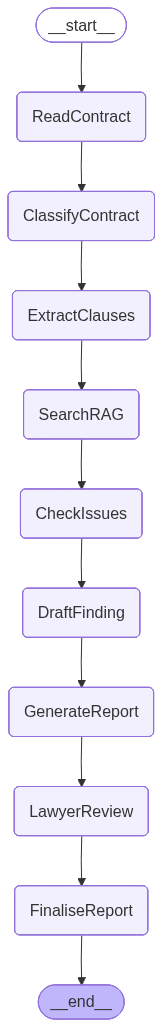

In [38]:
Image(App.get_graph().draw_mermaid_png())